# Email Spam Detection

### Oasis Infobyte Internship – Task 4

**Name:** Srajan Shukla  
**Domain:** Data Science Internship 

## Objective
The main goal of this project is to create a Machine Learning model that can tell if a message is **Spam** or **Ham (Not Spam)**. We will use Natural Language Processing techniques to do this.
The steps we will take are:
- We will load the dataset and look at what's, in it
- We will clean up the text data
- We will change the text into numbers using TF-IDF so the Machine Learning model can understand it
- We will train many different Machine Learning models
- We will see how well each model is doing using standard tests
- We will compare the models and talk about why it is so important to remember the **Spam** messages when we are trying to detect **Spam**

## Dataset Information
This project uses the **SMS Spam Collection Dataset**. The **SMS Spam Collection Dataset** is something that people can get to for free. It is often used to help figure out what is spam and what is not.
**Things You Can Find In The Dataset:**
- **label:** This tells you if a message is **ham** or **spam**
- **message:** This is the text that someone sent in the SMS message
The **SMS Spam Collection Dataset** has messages from phones, not emails.. People still use the **SMS Spam Collection Dataset** to learn about and test ways to find spam because it is similar to looking at emails. Both are about deciding if some text is good or bad. The **SMS Spam Collection Dataset** is helpful, for this.

## Importing Required Libraries
In this section, we import the Python libraries required for data manipulation, text preprocessing, visualization, feature extraction, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,)

In [2]:
df=pd.read_csv("spam.csv",encoding="latin-1")

In [3]:
df.head(9)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

## Exploring the Dataset

Before preprocessing the data, it is important to understand the dataset's structure, data types, summary statistics, and identify any missing values.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## Handling Missing Values

The dataset was checked for missing values using `isnull().sum()`. The columns `Unnamed: 2`, `Unnamed: 3`, and `Unnamed: 4` contain almost entirely missing values and are not useful for spam classification. Therefore, these columns will be removed, and only the relevant columns (`v1` and `v2`) will be retained.

In [8]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [9]:
df.rename(columns={'v1': 'label','v2': 'message'}, inplace=True)

In [10]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Class Distribution

Before training a Machine Learning model, it is important to understand the distribution of classes in the dataset. This helps identify whether the dataset is balanced or imbalanced, which can influence model performance.

In [11]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [12]:
df['label'].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

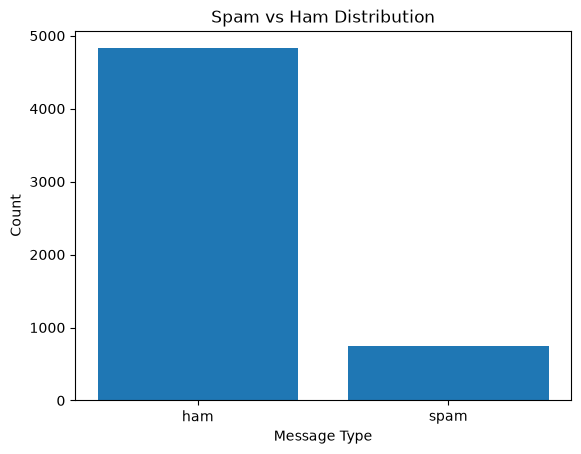

In [13]:
counts = df['label'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

## Text Preprocessing

Raw text cannot be directly used to train a Machine Learning model. Therefore, the text is preprocessed by converting it to lowercase, removing punctuation and special characters, and eliminating common stopwords. This helps reduce noise and improves the quality of the extracted features.

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sraja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print(list(stop_words)[:10])

["shan't", 'have', "i'd", 'ain', 'd', 'about', "they're", 'when', 'i', 'my']


In [16]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [17]:
df['message'] = df['message'].apply(preprocess)
df.head()

,label,message
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts st ...
3,ham,u dun say early hor u c already say
4,ham,nah dont think goes usf lives around though


## Feature Extraction using TF-IDF

Machine Learning models cannot understand text directly. Therefore, the cleaned text messages are converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) Vectorizer.TF-IDF assigns higher importance to words that appear frequently in a particular document but are less common across the entire dataset. This helps the model focus on more meaningful words while reducing the influence of very common words.

In [18]:
tv = TfidfVectorizer()
X = tv.fit_transform(df['message'])
Y = df['label']

In [19]:
print(X.shape)

(5572, 8390)


In [20]:
type(X)

scipy.sparse._csr.csr_matrix

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3,random_state=69)

In [22]:
print(X_train.shape)

(3900, 8390)


In [23]:
print(X_test.shape)

(1672, 8390)


In [24]:
print(y_train.shape)
print(y_test.shape)

(3900,)
(1672,)


# Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most commonly used algorithms for text classification. It works well with word-frequency and TF-IDF features and is widely used for spam detection.

In [25]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [26]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

## Model Evaluation - Accuracy

Accuracy measures the percentage of correctly classified messages out of the total number of messages.Accuracy = (Correct Predictions / Total Predictions) × 100. Although accuracy is useful, it may not be sufficient for spam detection because datasets can be imbalanced.

In [27]:
accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy)

Accuracy: 0.9593301435406698


## Precision

Precision measures how many messages predicted as spam were actually spam.Precision = True Positives / (True Positives + False Positives). A high precision means the model rarely marks legitimate (ham) emails as spam.

In [28]:
precision = precision_score(y_test, y_pred_nb, pos_label='spam')
print("Precision:", precision)

Precision: 1.0


## Recall

Recall measures how many actual spam messages were correctly identified by the model. Recall = True Positives / (True Positives + False Negatives). A high recall means the model misses very few spam messages, making it an important metric for spam detection.

In [29]:
recall = recall_score(y_test, y_pred_nb, pos_label='spam')
print("Recall:", recall)

Recall: 0.7178423236514523


In [30]:
f1 = f1_score(y_test, y_pred_nb, pos_label='spam')
print("F1-Score:", f1)

F1-Score: 0.8357487922705314


## Confusion Matrix

A confusion matrix is really helpful because it shows us the number of wrong predictions made by the model.
It has four values.
These are:
* Positive: This is when the model says something is spam and it really is spam.
* Negative: This is when the model says something is not spam, which is also correct so it is ham.
* False Positive: This happens when the model thinks something is spam. It is actually ham.
* False Negative: This is when the model thinks something is not spam. It really is spam.
The confusion matrix is about the model and its predictions, like the number of correct predictions and incorrect predictions made by the model.

In [31]:
cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

[[1431    0]
 [  68  173]]


In [32]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.98      1431
        spam       1.00      0.72      0.84       241

    accuracy                           0.96      1672
   macro avg       0.98      0.86      0.91      1672
weighted avg       0.96      0.96      0.96      1672



## Logistic Regression

It is a supervised machine learning classification algorithm used to predict the probability of a message belonging to a particular class. It is commonly used for binary classification problems such as spam detection.

In [33]:
lr_model = LogisticRegression(random_state=69)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

Accuracy: 0.9449760765550239
              precision    recall  f1-score   support

         ham       0.94      1.00      0.97      1431
        spam       0.99      0.63      0.77       241

    accuracy                           0.94      1672
   macro avg       0.96      0.81      0.87      1672
weighted avg       0.95      0.94      0.94      1672

[[1429    2]
 [  90  151]]


## Model Comparison

We used Multinomial Naive Bayes and Logistic Regression for spam detection. Both Multinomial Naive Bayes and Logistic Regression were trained on TF-IDF features.
- **Multinomial Naive Bayes** is a model that works fast and does a good job with text classification tasks like spam detection with Multinomial Naive Bayes.
- **Logistic Regression** is another model that often does a job by learning a linear decision boundary for spam detection with Logistic Regression.
- To find out which model is better we need to compare the accuracy, precision, recall and F1-score of Multinomial Naive Bayes and Logistic Regression, on the test set.

In [35]:
comparison = pd.DataFrame({'Model': ['Multinomial Naive Bayes', 'Logistic Regression'],'Accuracy': [accuracy_score(y_test, y_pred_nb),
                                                                                                    accuracy_score(y_test, y_pred_lr)],
                           'Precision': [precision_score(y_test, y_pred_nb, pos_label='spam'),
                                         precision_score(y_test, y_pred_lr, pos_label='spam')],
                           'Recall': [recall_score(y_test, y_pred_nb, pos_label='spam'),
                                      recall_score(y_test, y_pred_lr, pos_label='spam')],
                           'F1-Score': [f1_score(y_test, y_pred_nb, pos_label='spam'),
                                        f1_score(y_test, y_pred_lr, pos_label='spam')]})
print(comparison)

                     Model  Accuracy  Precision    Recall  F1-Score
0  Multinomial Naive Bayes  0.959330   1.000000  0.717842  0.835749
1      Logistic Regression  0.944976   0.986928  0.626556  0.766497


# Conclusion

In this project, two machine learning models were trained to classify SMS messages as spam or ham using TF-IDF features.
After comparing the evaluation metrics, **Multinomial Naive Bayes** achieved better overall performance than **Logistic Regression** on this dataset.
- Multinomial Naive Bayes achieved an accuracy of **95.93%**, while Logistic Regression achieved **94.50%**.
- Naive Bayes also achieved higher recall and F1-score, meaning it detected more spam messages while maintaining excellent precision.
- Since recall is important in spam detection to minimize missed spam messages, Multinomial Naive Bayes proved to be the more suitable model for this dataset.
Overall, the project demonstrated how text preprocessing, TF-IDF vectorization, and machine learning algorithms can be combined to build an effective spam detection system.

## WordCloud Visualization

WordCloud is a visualization technique that displays the most frequently occurring words in a collection of text. Larger words represent higher frequency, while smaller words appear less often.
In this project, separate WordClouds are generated for **spam** and **ham** messages to visualize the most common words in each category.

In [36]:
from wordcloud import WordCloud

In [37]:
spam = " ".join(df[df['label'] == 'spam']['message'])

In [38]:
spamc = WordCloud(width=800,height=400,background_color='white').generate(spam)

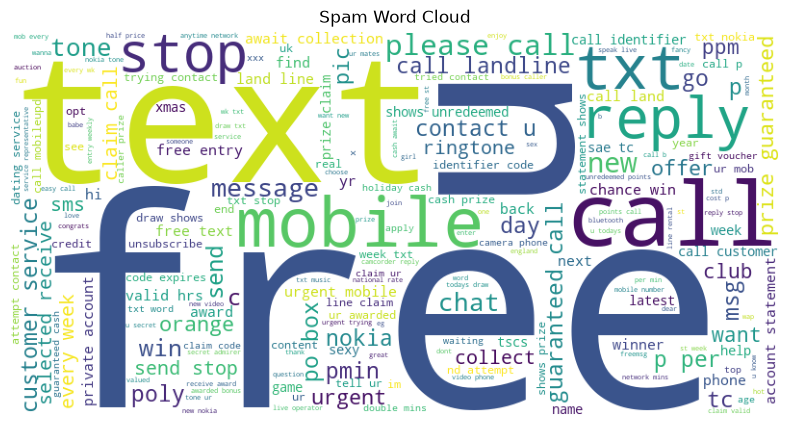

In [39]:
plt.figure(figsize=(10,5))
plt.imshow(spamc)
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()

In [40]:
ham = " ".join(df[df['label'] == 'ham']['message'])

In [41]:
hamc = WordCloud(width=800,height=400,background_color='white').generate(ham)

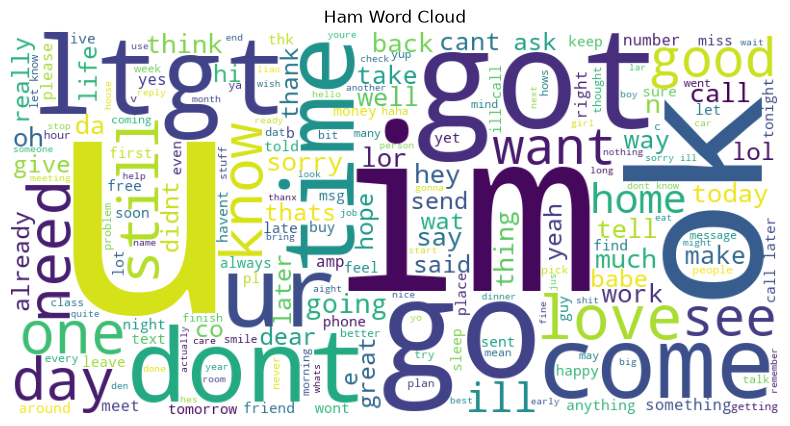

In [42]:
plt.figure(figsize=(10,5))
plt.imshow(hamc)
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()